# 6.2 Camera Thermal-Elastic Drift

In this notebook we take a closer look at the inclusion of the Thermal-Elastic Drift (TED) for a PLATO camera. 

We note that the drift motion from the Differential Kinematic Abbreviation (DKA; which varies across the FOV as a function of the velocity vector of the spacescraft's motion) is already implemented in PlatoSim. In theory the DKA can be as high as 20 arcsec (i.e. 1.3 pixel in CCD focal plane) in 3 months. However, this is the level of DKA one would have in principle with a field of view of 90° (in radius). Although large, the PLATO FOV is no larger than ~28° (in radius) such that the DKA is not going to exceed ~0.8 pixel in 3 months.

The mission requirements the TED induced by the platform is not allowed to exceed 0.4 pixel. In practice according to mission contractor called Prime, this is not going to exceed 1/50 pixel in 3 months. Accordingly, the DKA should be the dominant source of drift. Since the latter is fully predictable this can simplify a lot the current mask update strategy (PLATO-LESIA-PDC-DD-0022, i1.0). Indeed, the current one assumes than the drift is not predictable and thus has to be monitored continuously during the quarter for all stars (and all cameras).

### Setup notebook

In [83]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [84]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from scipy.interpolate import make_interp_spline
from scipy.ndimage import median_filter
from scipy import constants as c

from platosim.noise import *
from platosim.plot import *

---
## 6.2.1 - Red noise drift model
---


---
## 6.2.1 - Polynomial drift model
---


---
## 6.1.2 - Dynamic drift model (from Prime)
---

The Prime is delivering the coefficients of the rotations matrices transforming the pointing directions in the
PLM (payload module) reference frame, so-called **Quarternions**.

Load Prime TED (sampling = 1 h,  duration = 90 d)

In [263]:
# Load file
path = '/lhome/nicholas/Nextcloud/Platoman/Models'
filename = f'{path}/Jitter/2021january/04_rev349_ARC3_EOL_90d_3600.csv'
rows = ['time', 
        'd11', 'r11', 'd12', 'r12', 'd13', 'r13', 'd14', 'r14', 'd15', 'r15', 'd16', 'r16',
        'd21', 'r21', 'd22', 'r22', 'd23', 'r23', 'd24', 'r24', 'd25', 'r25', 'd26', 'r26', 
        'd31', 'r31', 'd32', 'r32', 'd33', 'r33', 'd34', 'r34', 'd35', 'r35', 'd36', 'r36',
        'd41', 'r41', 'd42', 'r42', 'd43', 'r43', 'd44', 'r44', 'd45', 'r45', 'd46', 'r46']
df = pd.read_csv(filename, sep=';', skiprows=7, names=rows, decimal=',', 
                 usecols=range(len(rows)))

# Timings
N = 35
df.time = df.time - df.time.iloc[0]
time = df.time.to_numpy()[N:]/86400
dt = np.diff(time)[0]
df_nyq = 1/(2*dt)
df_res = dt/10

df.head()

,time,d11,r11,d12,r12,d13,r13,d14,r14,d15,...,d42,r42,d43,r43,d44,r44,d45,r45,d46,r46
0,0,0.002366,-0.001379,0.002811,-0.001190,0.002952,-0.000844,0.001491,-0.001372,0.001301,...,0.003441,-0.000821,0.002692,-0.001008,0.002246,-0.000726,0.003248,-0.000956,0.003238,-0.000927
1,3600,0.004327,-0.002595,0.005172,-0.002178,0.005474,-0.001554,0.002588,-0.002509,0.002418,...,0.006367,-0.001487,0.004962,-0.001861,0.004168,-0.001324,0.005810,-0.001661,0.006022,-0.001715
2,7200,0.005519,-0.003605,0.006745,-0.002939,0.007282,-0.002042,0.003629,-0.003488,0.003283,...,0.008610,-0.002013,0.006912,-0.002496,0.005340,-0.001784,0.007915,-0.002273,0.008105,-0.002315
3,10800,0.006278,-0.004434,0.008020,-0.003554,0.008636,-0.002512,0.004611,-0.004214,0.004331,...,0.009960,-0.002432,0.008139,-0.003098,0.006194,-0.002184,0.008988,-0.002704,0.009273,-0.002784
4,14400,0.007296,-0.005096,0.009329,-0.004084,0.009977,-0.002870,0.005501,-0.004893,0.005245,...,0.011652,-0.002752,0.009450,-0.003556,0.006911,-0.002485,0.010298,-0.003067,0.010694,-0.003188


<IPython.core.display.Javascript object>


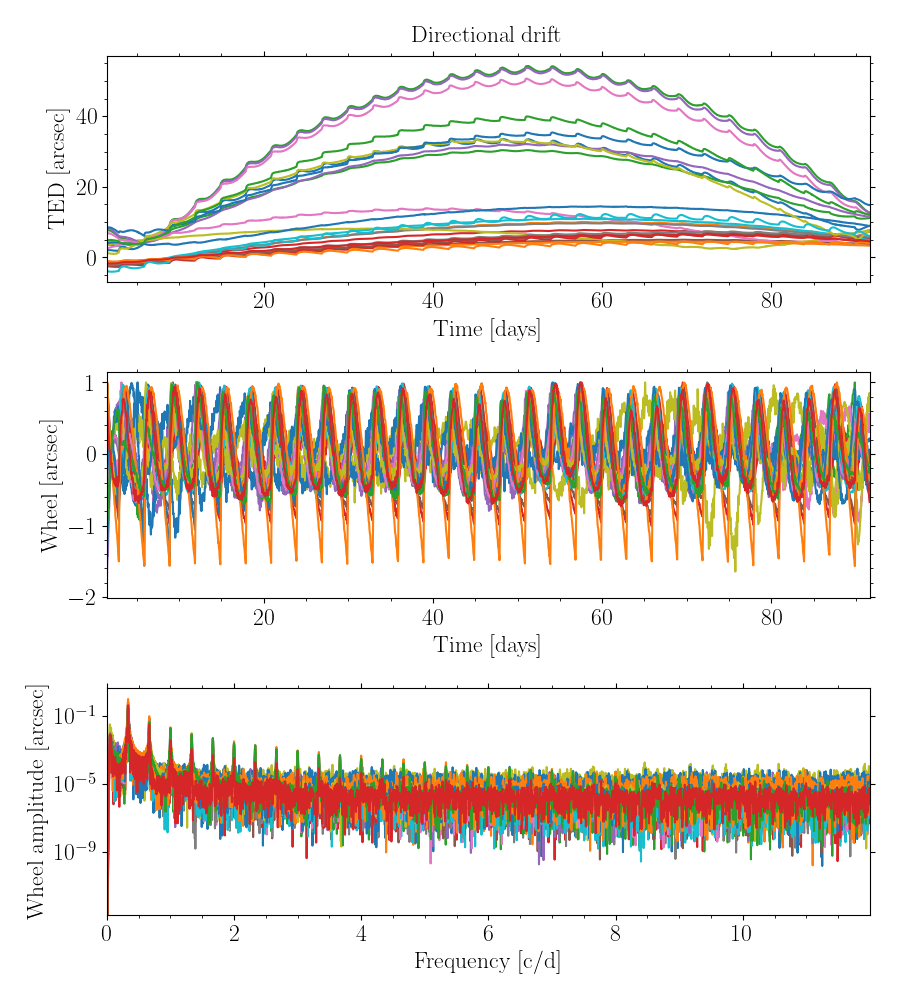

In [275]:
# Switch on directional (n=1) or rotational (n=2)
n = 1
s = 2e2
dt = pd.DataFrame()
dt['time'] = time * 86400

fig, ax = plt.subplots(3, 1, figsize=(9,10))
for i in range(24):
    
    # Plot TED
    ted = df[rows[i+n]].to_numpy()[N:] * s
    ax[0].plot(time, ted)
    
    # Plot wheel offloadings only
    poly  = np.polyfit(time, ted, deg=10)
    trend = np.polyval(poly, time)
    wheel = (ted - trend) 
    # Recenter around zero
    wheel -= wheel.mean()
    wheel /= wheel.max()
    ax[1].plot(time, wheel)
    dt[f'ncam{i+1}'] = wheel
    
    # Apply relative amplitude to TED
#     ampl = (wheel.max()-wheel.min()) / (ted.max()-ted.min()) * 100
    
    # Plot DFT spectrum
    fdir, adir = ns.DFTpower(time, wheel, f0=0, fn=df_nyq, df=df_res) 
    ax[2].plot(fdir, adir)

if   n == 1:
    name = 'dir'
    ax[0].set_title('Directional drift', pad=10)
elif n == 2: 
    name = 'rot'
    ax[0].set_title('Rotational drift', pad=10)     

ax[0].set_ylabel('TED [arcsec]')
ax[0].set_xlabel('Time [days]')
ax[0].set_xlim(time[0], time[-1])

ax[1].set_ylabel('Wheel [arcsec]')
ax[1].set_xlabel('Time [days]')
ax[1].set_xlim(time[0], time[-1]) 

ax[2].set_ylabel('Wheel amplitude [arcsec]')
ax[2].set_xlabel('Frequency [c/d]')
ax[2].set_yscale('log')
ax[2].set_ylim(1e-15*s, 1e-4*s**2)
ax[2].set_xlim(fdir[0], fdir[-1])  

plt.tight_layout() 
dt.to_feather(f'{os.getenv("PLATO_PROJECT_HOME")}/inputfiles/TED_{name}_prime_2021jan.ftr')

In [241]:
(dt.time.iloc[-1] - dt.time.iloc[0])/86400

90.16666666666667

In [273]:
np.random.uniform(0,0.1)

0.028076167217224703

### Plot TED time series (cartesian + rotational)

<IPython.core.display.Javascript object>


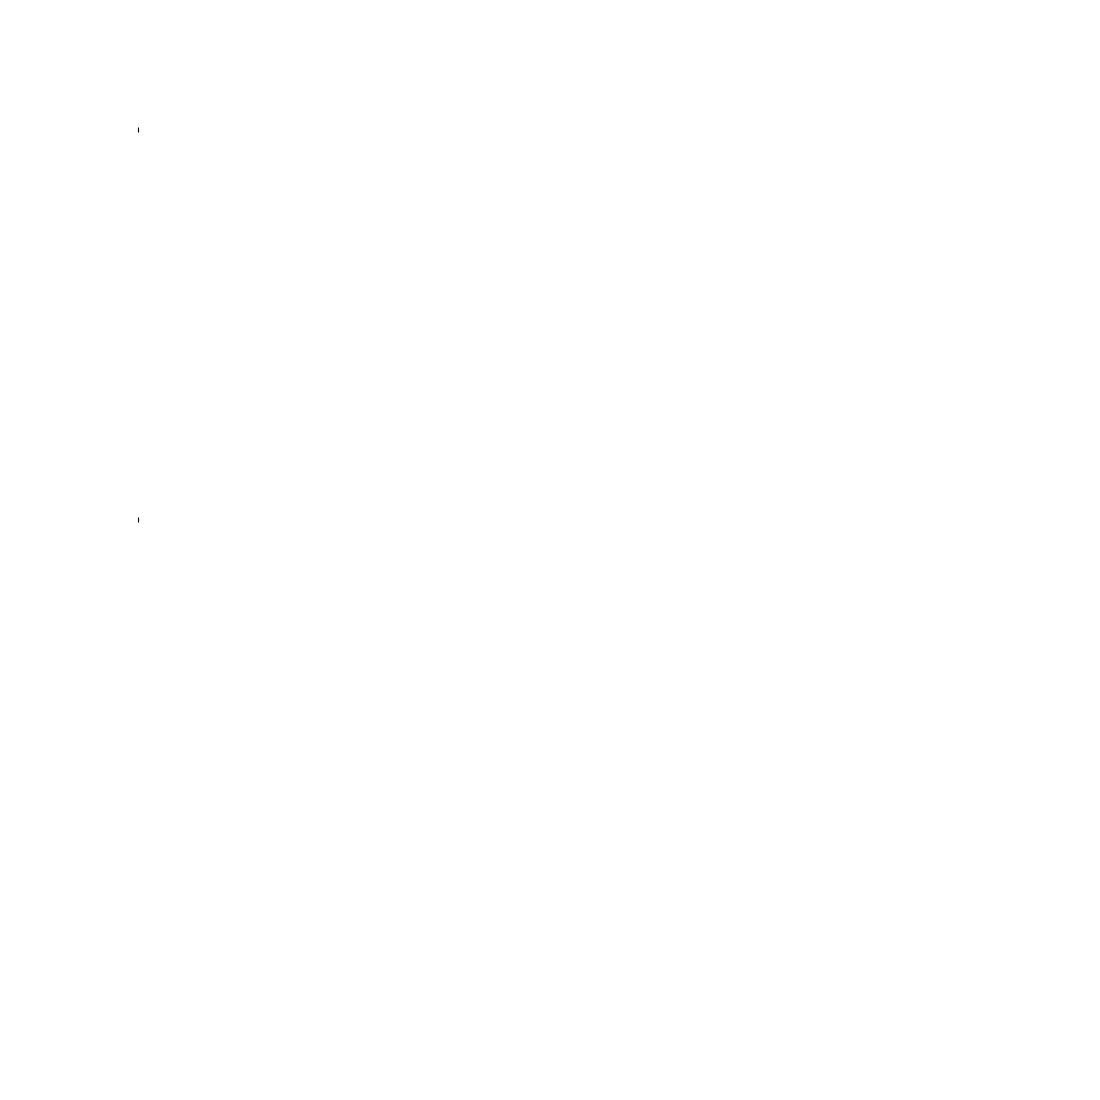

ValueError: x and y must have same first dimension, but have shapes (2200,) and (25,)

In [28]:
# Prepare a mean calculation
# ted_dir = np.zeros((24,len(data)))
# ted_rot = np.zeros((24,len(data)))
# Prepare for plotting
color = cm.rainbow(np.linspace(0,1,49))


fig, ax = plt.subplots(2, 1, figsize=(11,11))

for i,c in zip(range(df.shape[1]-1), color):
    
    # Plot even number i.e. directional in file
    if i % 2 == 0:
        ax[0].plot(df.time/86400., df.loc[i+1], '-', c=c, label='{}'.format(cams[int(i/2)]))
#         ted_dir[int(i/2),:] = data[:,i+1]
        
    # Plot odd number i.e. rotational in file
#     if i % 2 != 0:
#         ax[1].plot(time_ted/86400., data[:,i+1], '-', c=c, label='{}'.format(cams[int(i/2)]))
#         ted_rot[int(i/2),:] = data[:,i+1]
        
# Find mean values
# ted_dir_mean = np.mean(ted_dir, axis=0)
# ted_rot_mean = np.mean(ted_rot, axis=0)          

# Plot mean values
ax[0].plot(time_ted/86400., ted_dir_mean, 'k-', lw=5, label='Mean')  
ax[1].plot(time_ted/86400., ted_rot_mean, 'k-', lw=5, label='Mean')  

# Plot settings
ax[0].set_title('Cartesian TED')   
ax[1].set_title('Rotational TED')   
ax[1].set_xlabel('Time [days]')
ax[0].set_ylabel('Amplitude [arcsec]')
ax[1].set_ylabel('Amplitude [arcsec]')
ax[0].legend(bbox_to_anchor=(1.01, 0.8))
plt.show()

# Save figure
#fig.savefig('/home/nicholas/Nextcloud/presentations/presentation_PW12/plotPrimeTED.png', bbox_inches='tight', dpi=300)

In [ ]:

a = np.array([time_ted, ted_dir[0], ted_dir[0], ted_rot[0]])
print(a.T)
np.savetxt('/home/nicholas/software/python/platonium/models/drift_Ncam1.1_Q1.txt', a.T)

Plot TED PSD

In [ ]:
# First subtract the mean

_, PSD_dir_mean = powerDensityFFT(ted_dir_mean-np.mean(ted_dir_mean)+1, samp_ted)
_, PSD_rot_mean = powerDensityFFT(ted_rot_mean-np.mean(ted_rot_mean)+1, samp_ted)

# Prepare a mean calculation

import math

PSD_dir  = []
PSD_rot  = []
freq_ted = []

for i in range(24):
    
    ted_dir_i = ted_dir[i] - np.mean(ted_dir[i])
    ted_rot_i = ted_rot[i] - np.mean(ted_rot[i])

    freq_ted_i, PSD_dir_i = powerDensityFFT(ted_dir_i, samp_ted)
    _,          PSD_rot_i = powerDensityFFT(ted_rot_i, samp_ted)
    
    freq_ted.append(freq_ted_i)
    PSD_dir.append(PSD_dir_i)
    PSD_rot.append(PSD_rot_i)
   
# Plot Directional TED
fig = plt.figure(figsize=(10,5))
plotPSD(fig, freq_ted, PSD_dir, carbox=False, linewidth=2, xlim=[1e-7, np.max(freq_ted)], ylim=[1e-6, 1e4], 
        units=['Hz', 'arcsec'], title='PSD TED directional', misreq=True)
plt.show()

# PLot Rotational TED
fig = plt.figure(figsize=(10,5))
plotPSD(fig, freq_ted, PSD_rot, carbox=False, linewidth=2, xlim=[1e-7, np.max(freq_ted)], ylim=[1e-6, 1e4], 
        units=['Hz', 'arcsec'], title='PSD TED directional', misreq=True)
plt.show()

# Plot Mean TED
fig = plt.figure(figsize=(10,5))
plotPSD(fig, freq_ted, [PSD_dir_mean, PSD_rot_mean], carbox=False, linewidth=2, xlim=[1e-7, np.max(freq_ted)], ylim=[1e-6, 1e4], 
        units=['Hz', 'arcsec'], title='PSD TED directional', misreq=True)
plt.show()

In [4]:
# Interpolate (piecewise cubic) into higher resolution grid
grid_no  = int(time_ted[-1]/25.)
time_int = np.linspace(time_ted[0], time_ted[-1], grid_no)
samp_int = 25.

# All 24 cams
ted_int_dir = np.zeros((24, grid_no))
ted_int_rot = np.zeros((24, grid_no))

for i in range(24):
    grid_dir = make_interp_spline(time_ted, ted_dir[i], k=3)
    grid_rot = make_interp_spline(time_ted, ted_rot[i], k=3)
    ted_int_dir[i,:] = grid_dir(time_int)
    ted_int_rot[i,:] = grid_rot(time_int)

# Mean values
ted_int_dir_mean = np.mean(ted_int_dir, axis=0)
ted_int_rot_mean = np.mean(ted_int_rot, axis=0)
    
# Find freq and PSD
freq_ted_int, PSD_int_dir_mean = powerDensityFFT(ted_int_dir_mean, samp_int)

freq_jitter, PSD_xJitter = powerDensityFFT(data_jitter_prime[0], samp_jitter)
_,           PSD_yJitter = powerDensityFFT(data_jitter_prime[1], samp_jitter)
_,           PSD_zJitter = powerDensityFFT(data_jitter_prime[2], samp_jitter)

freq = [freq_ted[20], freq_jitter]
PSDx  = [PSD_dir[20], PSD_xJitter]
PSDy  = [PSD_dir[20], PSD_yJitter]
PSDz  = [PSD_rot[20], PSD_zJitter]

# Plot new interpolation for PSD
fig0 = plt.figure(figsize=(9,3.5))
plotPSD(fig0, freq, PSDx, carbox=100, linewidth=1, colors=['c', 'lightgreen'], units=['Hz', 'arcsec'], 
        xlim=[1e-6, np.max(freq_jitter)], ylim=[1e-12, 1e3], misreq=True,
        labels=['TED Dir', 'AOCS Yaw', 'Jitter Yaw'], title='PSD TED directional')
plt.show()

fig1 = plt.figure(figsize=(9,3.5))
plotPSD(fig1, freq, PSDy, carbox=100, linewidth=1, colors=['c', 'limegreen'], units=['Hz', 'arcsec'], 
        xlim=[1e-6, np.max(freq_jitter)], ylim=[1e-12, 1e3], misreq=True,
        labels=['TED Dir', 'AOCS Pitch', 'Jitter Yaw'], title='PSD TED directional')
plt.show()

fig2 = plt.figure(figsize=(9,3.5))
plotPSD(fig2, freq, PSDz, carbox=100, linewidth=1, colors=['b', 'g'], units=['Hz', 'arcsec'], 
        xlim=[1e-6, np.max(freq_jitter)], ylim=[1e-12, 1e3], misreq=True,
        labels=['TED Rot', 'AOCS Roll', 'Jitter Yaw'], title='PSD TED directional')
plt.show()

# Save figure
#fig0.savefig('/home/nicholas/Nextcloud/presentations/presentation_PW12/plotPrimePSDYaw.png', bbox_inches='tight', dpi=300)
#fig1.savefig('/home/nicholas/Nextcloud/presentations/presentation_PW12/plotPrimePSDPitch.png', bbox_inches='tight', dpi=300)
#fig2.savefig('/home/nicholas/Nextcloud/presentations/presentation_PW12/plotPrimePSDRoll.png', bbox_inches='tight', dpi=300)

NameError: name 'time_ted' is not defined

## Prime AOCS and TED time series with sampling = 12.5 s and duration = 27 d

In [ ]:
filename = '/home/nicholas/software/python/platonium/models/aocs_prime_2021-01/03_PLATO_PDR_AOCSandTED.csv'
data = np.loadtxt(filename, delimiter=';')

time = data[:,0]  # [s]
x    = data[:,1]  # [arcsec]
y    = data[:,2]  # [arcsec]
z    = data[:,3]  # [arcsec]
data = [x, y, z]

In [ ]:
# Plot time series of yaw, pitch, and roll

fig = plt.figure(figsize=(8,9))
axes = plotYawPitchRollTimeSeries(fig, time/3600., data, units=['hours', 'arcsec'], title='Jitter+TED from Prime')
plt.show()

In [ ]:
# Plot PSD of yaw, pitch, and roll for Red Noise jitter

fig = plt.figure(figsize=(8,9))
plotYawPitchRollPSD(fig, time, data, title='PSD jitter + TED from Prime', xmin=1e2, misreq=True)
plt.show()